In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/salader/dogsvscats


In [2]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import os

In [3]:
from numpy.random import shuffle
data_dir = "/kaggle/input/datasets/salader/dogsvscats/train"

test_dir = "/kaggle/input/datasets/salader/dogsvscats/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(256,256)
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(256,256)
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=(256,256),
    shuffle=False
)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.


I0000 00:00:1784536792.673277      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784536792.676315      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 20000 files belonging to 2 classes.
Using 4000 files for validation.
Found 5000 files belonging to 2 classes.


In [ ]:
# Data Agumentation

data_agumentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(0.05,0.05),
    tf.keras.layers.RandomZoom(0.1)
])

In [7]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, BatchNormalization, Flatten, Dense
from tensorflow.keras import layers, models, callbacks, regularizers

In [8]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(256,256,3)),

    data_agumentation,

    # first convolution layer
    layers.Conv2D(32, (3,3), activation='relu',padding='valid' ,kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(), # used for feature map normalization
    layers.MaxPool2D(pool_size=(2,2), strides=(2,2),padding='valid'),
    layers.Dropout(0.3),

    # conv layer block 2
    layers.Conv2D(64, (3,3), activation='relu',padding='valid' , kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPool2D(pool_size=(2,2), strides=(2,2), padding='valid'),
    layers.Dropout(0.3),

    #conv layer block 3
    layers.Conv2D(128, (3,3), activation='relu',padding='valid' , kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPool2D(pool_size=(2,2), strides=(2,2), padding='valid'),
    layers.Dropout(0.3),

    # flattern layer
    layers.Flatten(),

    # ann layer
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [11]:
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

checkpoint = callbacks.ModelCheckpoint('model.keras', monitor='val_loss', save_best_only=True)

In [12]:
history = model.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=[early_stopping, checkpoint])

Epoch 1/50


E0000 00:00:1784536895.179329      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_3_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


500/500 ━━━━━━━━━━━━━━━━━━━━ 115s 212ms/step - accuracy: 0.5620 - loss: 2.3564 - val_accuracy: 0.5088 - val_loss: 1.6365
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 103s 205ms/step - accuracy: 0.5693 - loss: 1.4435 - val_accuracy: 0.6097 - val_loss: 1.2176
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 101s 202ms/step - accuracy: 0.5869 - loss: 1.1553 - val_accuracy: 0.5462 - val_loss: 1.4612
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 201ms/step - accuracy: 0.5564 - loss: 1.8960 - val_accuracy: 0.5625 - val_loss: 1.9230
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 101s 201ms/step - accuracy: 0.6014 - loss: 1.2024 - val_accuracy: 0.5895 - val_loss: 0.9750
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 200ms/step - accuracy: 0.6033 - loss: 1.0031 - val_accuracy: 0.5508 - val_loss: 1.1195
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 100s 200ms/step - accuracy: 0.6241 - loss: 0.9221 - val_accuracy: 0.6513 - val_loss: 1.0883
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 101s 201ms/step - accuracy: 0.6383 - loss: 0.94

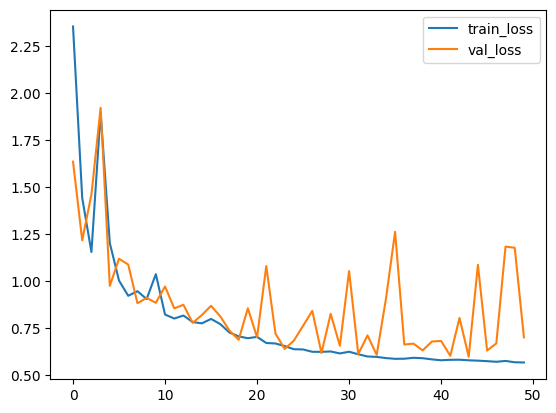

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

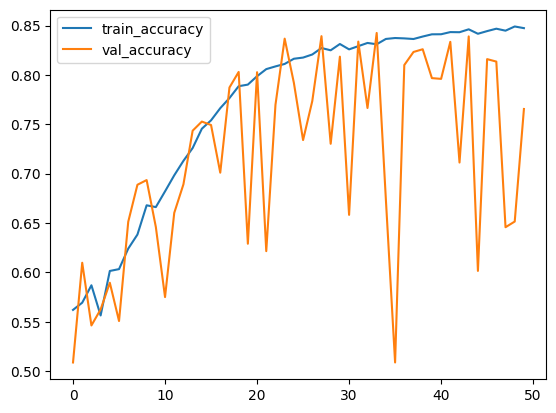

In [14]:
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

In [15]:
loaded_model = tf.keras.models.load_model("/kaggle/working/model.keras")

In [16]:
loss, accuracy = loaded_model.evaluate(test_ds)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.8310 - loss: 0.6067
Test Loss: 0.6067
Test Accuracy: 0.8310


In [30]:
print(train_ds.class_names)

['cats', 'dogs']


In [41]:
import numpy as np

def predict_image(path):
    img = tf.keras.utils.load_img(
        path,
        target_size=(256, 256)
    )
    
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = loaded_model.predict(img_array)
    
    probability = prediction[0][0]
    
    print("Raw Prediction:", probability)
    
    if probability > 0.5:
        return print("Predicted: Dog")
    else:
        return print("Predicted: Cat")

In [42]:
predict_image("/kaggle/input/datasets/rparyanreddy/img-prediction/cat.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Raw Prediction: 0.08798923
Predicted: Cat
